In [1]:
!pip install pmdarima

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima

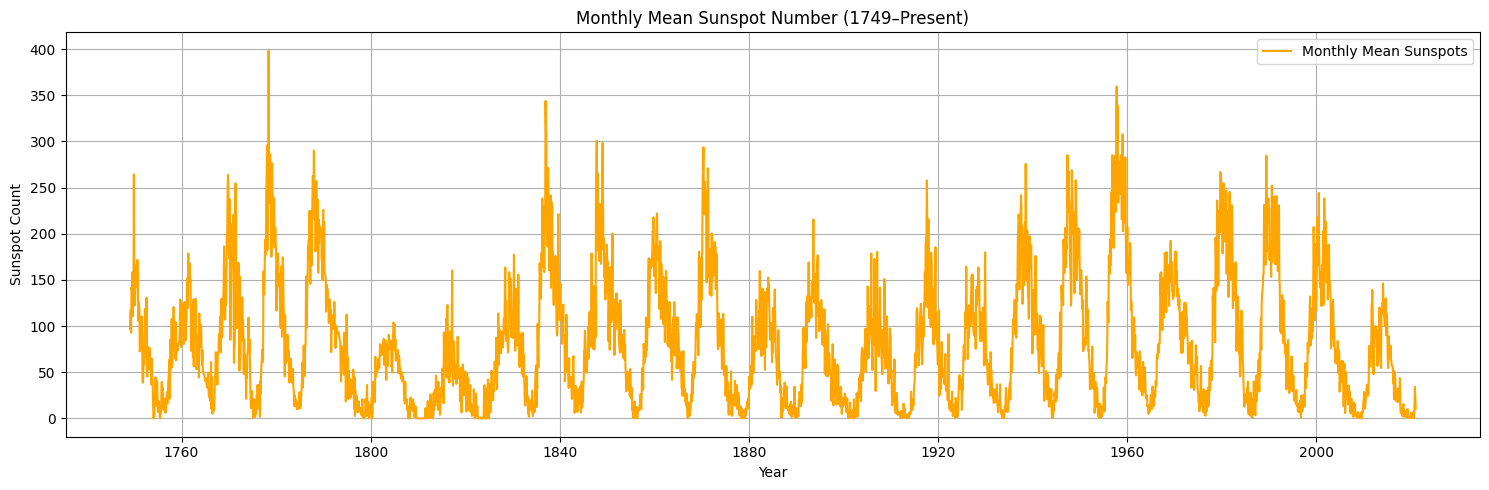

In [3]:
# 1. CSV 파일 불러오기
df = pd.read_csv('/content/Sunspots.csv')

# 2. 'Date' 컬럼을 datetime 형식으로 변환
df['Date'] = pd.to_datetime(df['Date'])

# 3. 'Date'를 인덱스로 설정
df.set_index('Date', inplace=True)

# 4. 컬럼명을 간단하게 변경 (접근 편의를 위해)
df.rename(columns={'Monthly Mean Total Sunspot Number': 'Sunspots'}, inplace=True)

# 5. 전체 시계열 시각화
plt.figure(figsize=(15, 5))  # 그래프 크기 설정
plt.plot(df['Sunspots'], label='Monthly Mean Sunspots', color='orange')  # 선 그래프 그리기
plt.title('Monthly Mean Sunspot Number (1749–Present)')  # 제목 설정
plt.xlabel('Year')  # x축 라벨
plt.ylabel('Sunspot Count')  # y축 라벨
plt.grid(True)  # 그리드 표시
plt.legend()  # 범례 표시
plt.tight_layout()  # 여백 자동 조정
plt.show()  # 그래프 출력


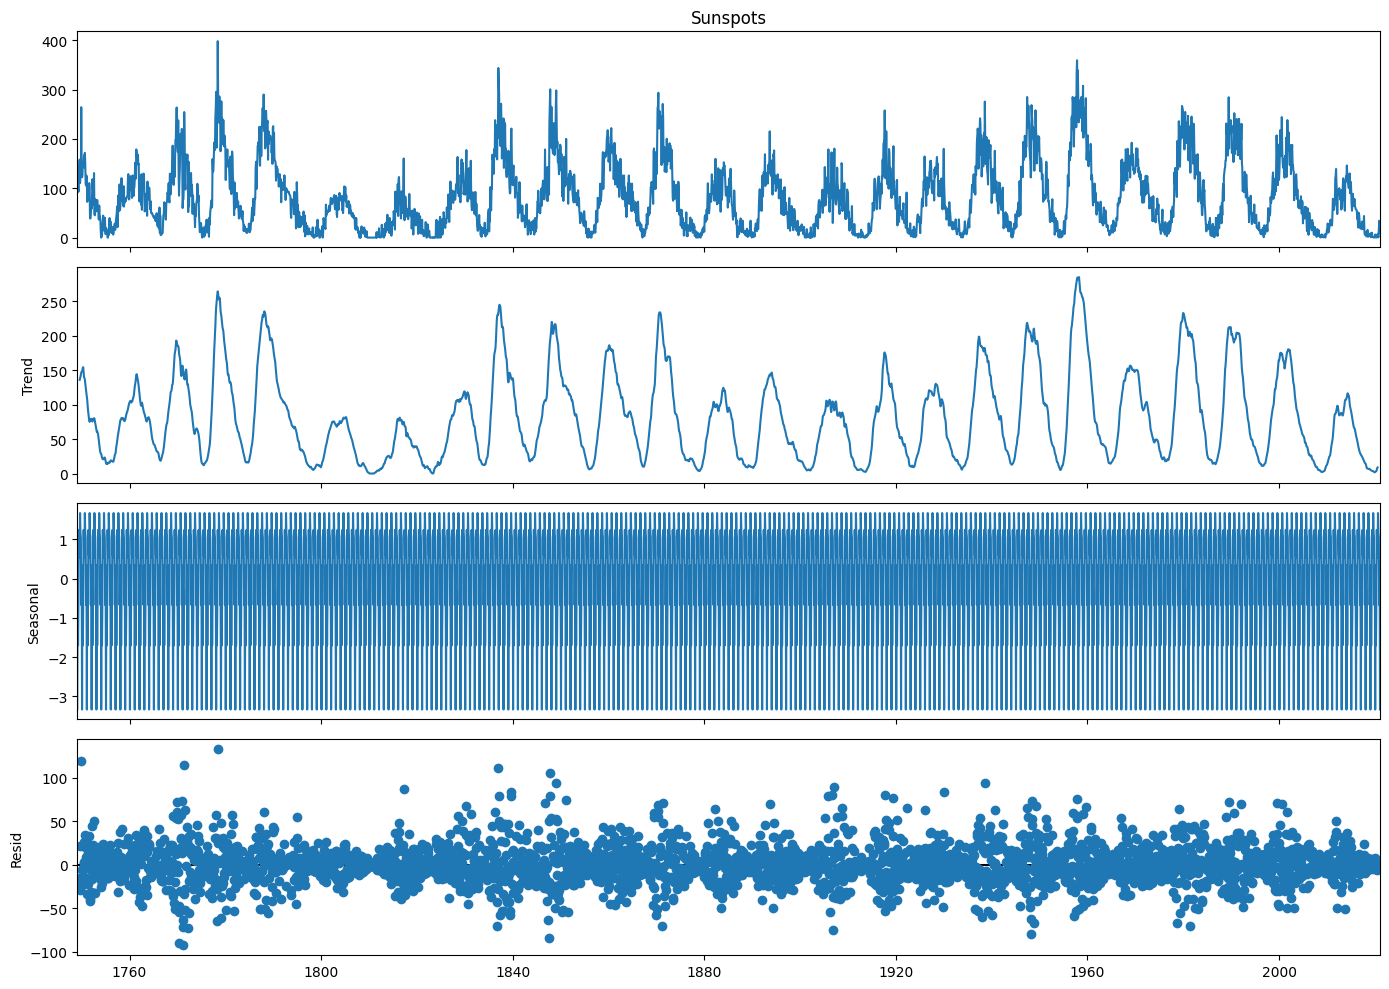

In [4]:
# 월별 흑점 수 데이터를 추세, 계절성, 잔차로 분해 (additive model 기준)
# 'additive'는 관측값 = 추세 + 계절성 + 오차로 구성된다고 가정
# period=12는 1년 주기를 의미 (월간 데이터이므로)
result = seasonal_decompose(df['Sunspots'], model='additive', period=12)

# 분해된 결과는 다음 네 부분으로 구성됨:
# - result.observed: 원래 시계열
# - result.trend: 장기 추세
# - result.seasonal: 계절 주기성
# - result.resid: 불규칙한 오차 성분

# 분해된 결과를 시각화
fig = result.plot()              # 네 구성요소를 각각 subplot으로 시각화
fig.set_size_inches(14, 10)      # 전체 그림의 크기를 지정
plt.tight_layout()               # 레이아웃 여백 자동 조정
plt.show()                       # 그래프 출력


<Figure size 1000x400 with 0 Axes>

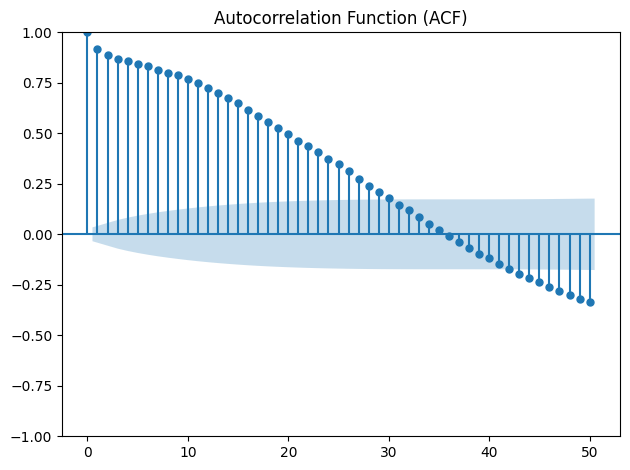

<Figure size 1000x400 with 0 Axes>

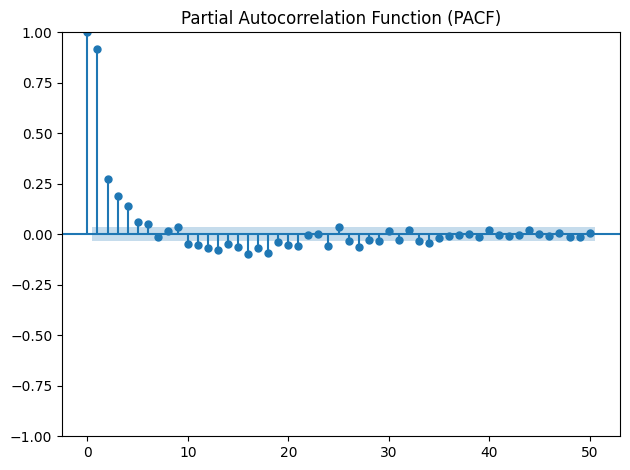

In [5]:
# ACF: 자기상관 함수
# 시계열의 현재 값과 과거 값들 사이의 상관관계를 시차별로 분석
# ARIMA 모델의 'q' (MA 차수) 결정에 도움
plt.figure(figsize=(10, 4))
plot_acf(df['Sunspots'], lags=50)  # 최대 시차 50까지 자기상관 계수 시각화
plt.title('Autocorrelation Function (ACF)')
plt.tight_layout()
plt.show()

# PACF: 부분 자기상관 함수
# 중간 시차의 영향을 제거하고 각 시차별 독립적인 상관성만 분석
# ARIMA 모델의 'p' (AR 차수) 결정에 도움
plt.figure(figsize=(10, 4))
plot_pacf(df['Sunspots'], lags=50, method='ywm')  # Yule-Walker 방식
plt.title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()


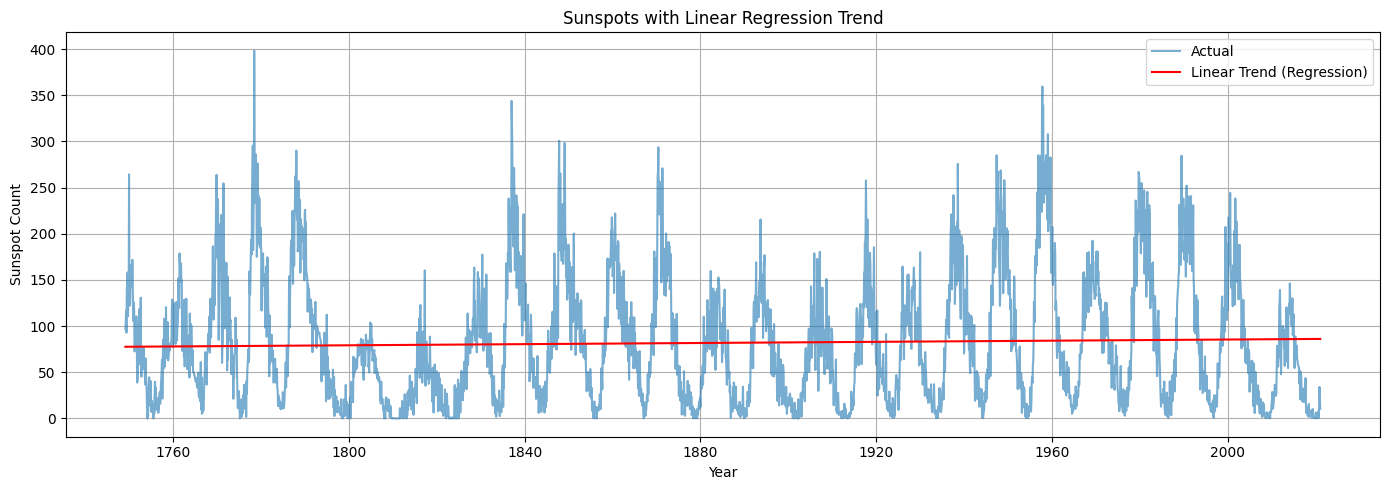

In [6]:
# 시간 인덱스를 숫자형 변수로 추가
# 선형 회귀는 숫자형 변수만 입력 가능하므로 날짜를 0, 1, 2... 순서로 변환
df['t'] = range(len(df))  # 0부터 시작하는 시간 순번

# 단순 선형 회귀 모델 학습
# t를 독립변수, Sunspots를 종속변수로 사용하여 추세선 도출
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(df[['t']], df['Sunspots'])  # t로부터 흑점 수를 예측

# 예측값 계산 (선형 추세선)
df['trend_pred'] = model.predict(df[['t']])

# 실제값과 추세선 시각화
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Sunspots'], label='Actual', alpha=0.6)  # 실제 흑점 수
plt.plot(df.index, df['trend_pred'], label='Linear Trend (Regression)', color='red')  # 회귀 추세선
plt.title('Sunspots with Linear Regression Trend')  # 그래프 제목
plt.xlabel('Year')  # x축: 연도
plt.ylabel('Sunspot Count')  # y축: 흑점 수
plt.legend()  # 범례 표시
plt.grid(True)  # 격자 표시
plt.tight_layout()  # 여백 자동 조정
plt.show()


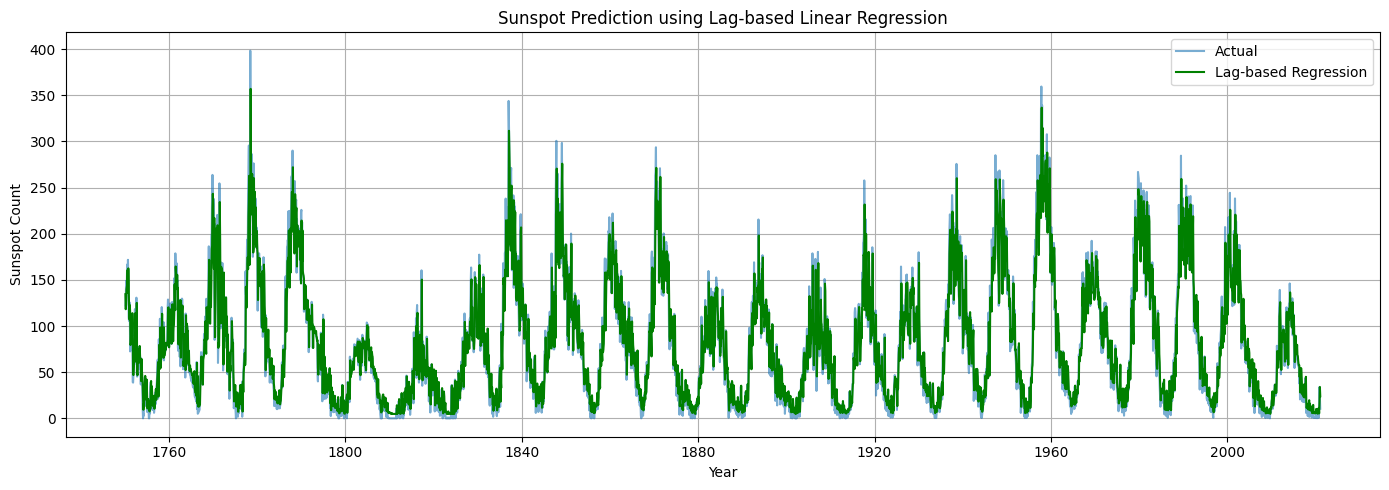

In [7]:
# 시차(lag) 기반 회귀 피처 생성
# y(t) ~ y(t-1) + y(t-12) 구조로 현재 시점 예측
# - y(t-1): 바로 직전 시점
# - y(t-12): 1년 전 동일한 달 (계절성 반영)
df['lag_1'] = df['Sunspots'].shift(1)
df['lag_12'] = df['Sunspots'].shift(12)

# NaN 발생 구간 제거 (초기 12개 행 제거됨)
df.dropna(inplace=True)

# 다중 선형 회귀 모델 학습
# - 입력 변수: lag_1, lag_12
# - 출력 변수: 현재 시점의 Sunspots
model = LinearRegression()
model.fit(df[['lag_1', 'lag_12']], df['Sunspots'])

# 예측값 계산 및 저장
df['regression_pred'] = model.predict(df[['lag_1', 'lag_12']])

# 실제값과 예측값 시각화
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Sunspots'], label='Actual', alpha=0.6)  # 실제값
plt.plot(df.index, df['regression_pred'], label='Lag-based Regression', color='green')  # 예측값
plt.title('Sunspot Prediction using Lag-based Linear Regression')
plt.xlabel('Year')  # x축: 연도
plt.ylabel('Sunspot Count')  # y축: 흑점 수
plt.legend()  # 범례 표시
plt.grid(True)  # 그리드 표시
plt.tight_layout()
plt.show()


In [8]:
# 1. 선형 회귀 모델 성능 평가
# - trend_pred: 시간(t)을 기반으로 한 선형 추세 예측
# - MAE: 예측 오차의 절대값 평균 (단위 유지)
# - RMSE: 큰 오차에 더 민감한 평균 제곱근 오차
mae_trend = mean_absolute_error(df['Sunspots'], df['trend_pred'])
rmse_trend = np.sqrt(mean_squared_error(df['Sunspots'], df['trend_pred']))

# 2. 시차 기반 회귀 모델 성능 평가
# - regression_pred: y(t-1), y(t-12)를 입력으로 예측한 흑점 수
mae_lag = mean_absolute_error(df['Sunspots'], df['regression_pred'])
rmse_lag = np.sqrt(mean_squared_error(df['Sunspots'], df['regression_pred']))

# 3. 성능 비교 출력
# - MAE/RMSE 값이 작을수록 예측력이 높음을 의미
print("선형 회귀 (시간 기반 추세선):")
print(f"MAE  = {mae_trend:.3f}")   # 절대 오차 평균
print(f"RMSE = {rmse_trend:.3f}")  # 제곱근 오차 평균

print("시차 기반 회귀 (lag_1, lag_12):")
print(f"MAE  = {mae_lag:.3f}")
print(f"RMSE = {rmse_lag:.3f}")


선형 회귀 (시간 기반 추세선):
MAE  = 55.052
RMSE = 67.819
시차 기반 회귀 (lag_1, lag_12):
MAE  = 18.924
RMSE = 26.440


In [9]:
# 1. 시차 피처 생성
# y(t) ~ y(t-1) + y(t-12)
df['lag_1'] = df['Sunspots'].shift(1)
df['lag_12'] = df['Sunspots'].shift(12)

# 결측치 제거 (처음 12개 시점은 NaN 발생)
df.dropna(inplace=True)

# 2. 독립변수(X)와 종속변수(y) 설정
X = df[['lag_1', 'lag_12']]  # 입력 변수: 이전 시점과 1년 전 시점의 흑점 수
y = df['Sunspots']           # 출력 변수: 현재 시점의 흑점 수

# 3. 상수항 추가 (절편 포함을 위해 상수열 추가)
X = sm.add_constant(X)  # const 열이 추가되어 절편(intercept) 포함 가능

# 4. OLS 회귀 모델 적합 (최소제곱법)
ols_model = sm.OLS(y, X).fit()

# 5. 상세 통계 요약 출력
# 회귀 계수, p-value, R-squared, F-statistic, Durbin-Watson 등
# 변수의 유의성, 모델 설명력, 잔차의 독립성 등 종합적으로 평가 가능
print(ols_model.summary())




                            OLS Regression Results                            
Dep. Variable:               Sunspots   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     9043.
Date:                Tue, 27 May 2025   Prob (F-statistic):               0.00
Time:                        11:57:51   Log-Likelihood:                -15215.
No. Observations:                3241   AIC:                         3.044e+04
Df Residuals:                    3238   BIC:                         3.045e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.7560      0.757      6.280      0.0

In [10]:
# ADF (Augmented Dickey-Fuller) 단위근 검정 수행
# → 시계열이 정상성(stationary)을 갖는지 판단
# 귀무가설(H0): 비정상 시계열 (unit root 존재)
# 대립가설(H1): 정상 시계열 (unit root 없음)
result = adfuller(df['Sunspots'])

# 결과 출력
print("ADF Statistic:", result[0])           # ADF 통계량 (더 작을수록 정상성 강함)
print("p-value:", result[1])                 # 유의확률 (0.05 미만이면 H0 기각 → 정상성 있음)
print("Critical Values:", result[4])         # 1%, 5%, 10% 유의수준의 임계값

# 해석 가이드를 위한 출력 보완
if result[1] < 0.05:
    print("결과: p-value < 0.05 → 정상성을 가진 시계열입니다.")
else:
    print("결과: p-value ≥ 0.05 → 비정상 시계열입니다. 차분이 필요할 수 있습니다.")

ADF Statistic: -10.497174063241395
p-value: 1.1077862721930425e-18
Critical Values: {'1%': -3.4323875260668344, '5%': -2.862440255934873, '10%': -2.5672492261933377}
결과: p-value < 0.05 → 정상성을 가진 시계열입니다.


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


수동 ARIMA(5,0,2):
MAE  = 53.81
RMSE = 56.98


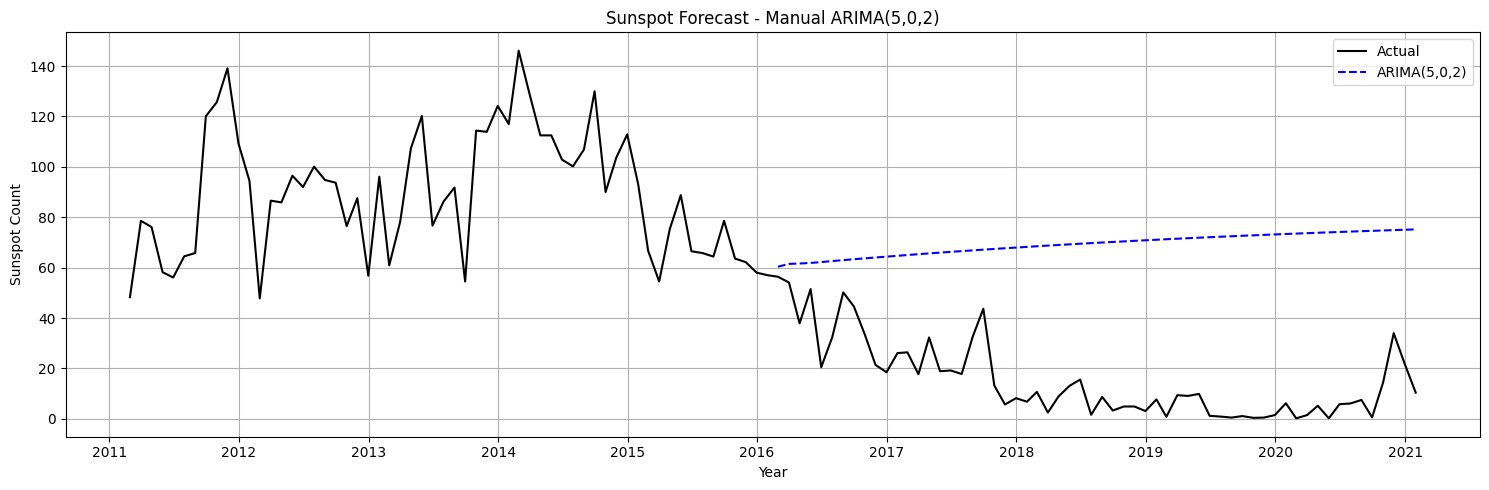

In [11]:
# 1. 학습/테스트 데이터 분할
# - 전체 시계열 중 마지막 60개월을 테스트 데이터로 사용
train = df['Sunspots'][:-60]
test = df['Sunspots'][-60:]

# 2. 수동 ARIMA 모델 정의 및 학습
# - ARIMA(p=5, d=0, q=2)
#   - p=5: 과거 5개월까지의 자기회귀
#   - d=0: 정상성 확인됨 (ADF)
#   - q=2: 이동 평균 계수 2개
model_manual = ARIMA(train, order=(5, 0, 2))
model_manual_fit = model_manual.fit()

# 3. 미래 60개월 예측
forecast_manual = model_manual_fit.forecast(steps=60)

# 4. 성능 평가 (정답인 test와 비교)
mae_manual = mean_absolute_error(test, forecast_manual)
rmse_manual = np.sqrt(mean_squared_error(test, forecast_manual))

# 5. 평가 지표 출력
print("수동 ARIMA(5,0,2):")
print(f"MAE  = {mae_manual:.2f}")   # 평균 절대 오차
print(f"RMSE = {rmse_manual:.2f}") # 평균 제곱근 오차

# 6. 예측 결과 시각화
plt.figure(figsize=(15, 5))
plt.plot(df.index[-120:], df['Sunspots'][-120:], label='Actual', color='black')  # 최근 10년 실제값
plt.plot(test.index, forecast_manual, label='ARIMA(5,0,2)', linestyle='--', color='blue')  # 예측값
plt.title('Sunspot Forecast - Manual ARIMA(5,0,2)')
plt.xlabel('Year')
plt.ylabel('Sunspot Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=29495.604, Time=14.86 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=30110.841, Time=0.44 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,1,1)(0,0,0)[0]             : AIC=29570.361, Time=1.25 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,1,3)(0,0,0)[0]             : AIC=29562.807, Time=3.54 sec

Best model:  ARIMA(2,1,2)(0,0,0)[0]          
Total fit time: 89.993 seconds
Auto ARIMA:
Best Order = (2, 1, 2)
MAE  = 20.81
RMSE = 22.80


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


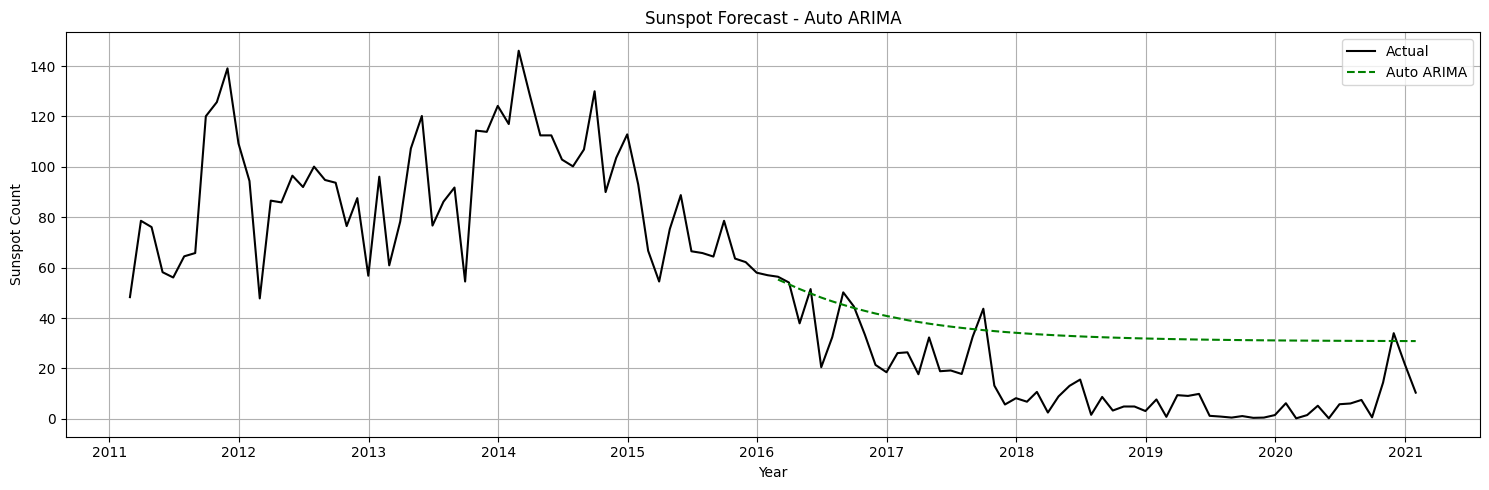

In [12]:
# 1. 시계열 분할: 마지막 60개월을 테스트 데이터로 사용
train = df['Sunspots'][:-60]
test = df['Sunspots'][-60:]

# 2. Auto ARIMA 학습
# - stepwise: 빠른 탐색 수행
# - seasonal=False: 계절성 없는 일반 ARIMA로 탐색 (SARIMA가 아님)
# - suppress_warnings=True: 로그 경고 제거
# - trace=True: 모델 탐색 로그 출력
model_auto = auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True, trace=True)

# 3. 60개월 예측 수행
forecast_auto = model_auto.predict(n_periods=60)

# 4. 성능 평가 (정답과 비교)
mae_auto = mean_absolute_error(test, forecast_auto)
rmse_auto = np.sqrt(mean_squared_error(test, forecast_auto))

# 5. 최적 모델 차수 및 평가 지표 출력
print("Auto ARIMA:")
print(f"Best Order = {model_auto.order}")  # 자동으로 선택된 (p, d, q)
print(f"MAE  = {mae_auto:.2f}")            # 평균 절대 오차
print(f"RMSE = {rmse_auto:.2f}")           # 평균 제곱근 오차

# 6. 예측 시각화
plt.figure(figsize=(15, 5))
plt.plot(df.index[-120:], df['Sunspots'][-120:], label='Actual', color='black')  # 실제값 (10년치)
plt.plot(test.index, forecast_auto, label='Auto ARIMA', linestyle='--', color='green')  # 예측값
plt.title('Sunspot Forecast - Auto ARIMA')
plt.xlabel('Year')
plt.ylabel('Sunspot Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
# 1. auto_arima가 선택한 최적 차수 (p, d, q) 출력
# AIC 기준으로 선택된 모델 구조 확인 가능
print("Best model:", model_auto.order)

# 2. 예측 수행: 학습 데이터(train) 이후 60개월을 예측
# 결과는 test 데이터셋과 비교하여 성능 평가
forecast_auto = model_auto.predict(n_periods=60)

# 3. 성능 평가 지표 계산
# MAE: 예측 오차의 절대값 평균 (평균적으로 얼마나 벗어났는가)
# RMSE: 큰 오차에 더 민감한 평균 제곱근 오차
mae = mean_absolute_error(test, forecast_auto)
rmse = np.sqrt(mean_squared_error(test, forecast_auto))

# 4. 결과 출력
print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")



Best model: (2, 1, 2)
MAE  = 20.81
RMSE = 22.80


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [14]:
# 모델 구조 및 통계 요약 출력 (AIC, BIC, 계수 등 포함)
print(model_auto.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3181
Model:               SARIMAX(2, 1, 2)   Log Likelihood              -14741.805
Date:                Tue, 27 May 2025   AIC                          29493.609
Time:                        11:59:31   BIC                          29523.932
Sample:                    01-31-1751   HQIC                         29504.484
                         - 01-31-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3336      0.021     63.553      0.000       1.292       1.375
ar.L2         -0.3839      0.021    -18.148      0.000      -0.425      -0.342
ma.L1         -1.7631      0.014   -128.880      0.0

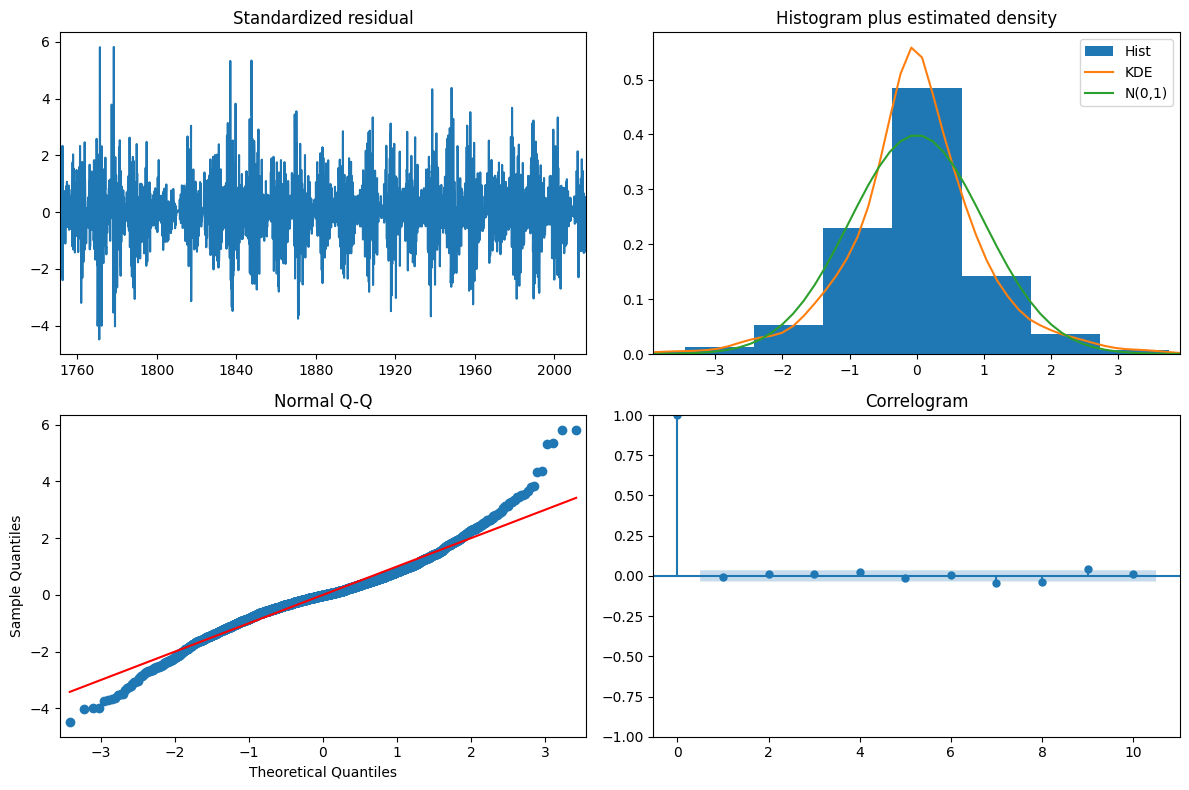

In [15]:
# 모델 적합성 시각화
model_auto.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(2,1,2)(1,1,1,12):
MAE  = 21.96
RMSE = 24.10


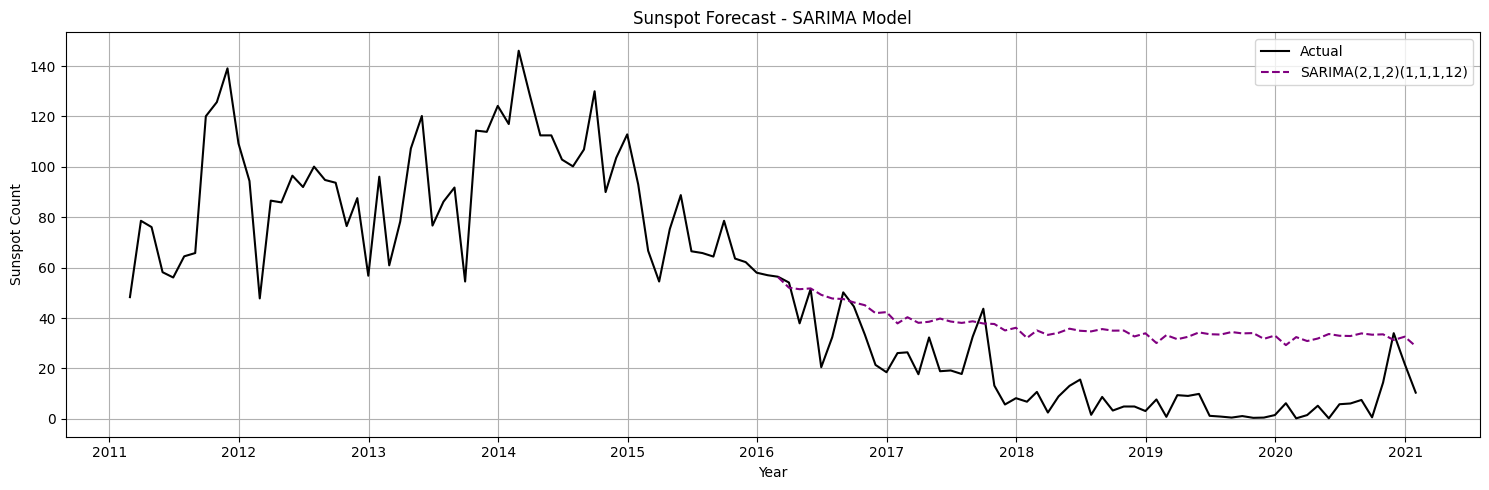

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 학습/테스트 분할
train = df['Sunspots'][:-60]
test = df['Sunspots'][-60:]

# SARIMA 모델 정의 및 학습
# (p, d, q) = (2, 1, 2), (P, D, Q, s) = (1, 1, 1, 12) → 기본적인 구조로 시작
model_sarima = SARIMAX(train,
                       order=(2, 1, 2),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
model_sarima_fit = model_sarima.fit(disp=False)

# 60개월 예측
forecast_sarima = model_sarima_fit.forecast(steps=60)

# 성능 평가
mae_sarima = mean_absolute_error(test, forecast_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test, forecast_sarima))

# 결과 출력
print("SARIMA(2,1,2)(1,1,1,12):")
print(f"MAE  = {mae_sarima:.2f}")
print(f"RMSE = {rmse_sarima:.2f}")

# 시각화
plt.figure(figsize=(15, 5))
plt.plot(df.index[-120:], df['Sunspots'][-120:], label='Actual', color='black')
plt.plot(test.index, forecast_sarima, label='SARIMA(2,1,2)(1,1,1,12)', linestyle='--', color='purple')
plt.title('Sunspot Forecast - SARIMA Model')
plt.xlabel('Year')
plt.ylabel('Sunspot Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
